# Sensor Alignment

A tutorial by Simon Ramirez

This notebook details the process of finding the alignment of a seismic sensor and then correcting its orientation.

## 0. Imports

In [ ]:
# For Configuration File
import yaml
from pathlib import Path
import importlib

config_path = ### Input the path to your config file ###
with open(config_path, "r") as f:
    config = yaml.safe_load(f)


name = config["name"]
seismic_path = config["seismic_data_path"]
seismic_data = Path(config['seismic_data_path'])
align_module = config['align_module']
process_module = config['process_module']


# obspy GitHub:
# https://github.com/obspy/obspy
from obspy import UTCDateTime as UTC

# seismic-data-quality GitHub: 
# https://github.com/Ramirezs873/seismic-data-quality
spec1 = importlib.util.spec_from_file_location("process", process_module)
process = importlib.util.module_from_spec(spec1)
spec1.loader.exec_module(process)

# seismic-sensor-anlysis GitHub:
# https://github.com/Ramirezs873/seismic-sensor-analysis
spec2 = importlib.util.spec_from_file_location("align", align_module)
align = importlib.util.module_from_spec(spec2)
spec2.loader.exec_module(align)



## 1. Gather Seismic Data



To gather seismic data, a premade function from a supplementary Library (align.py - seismic-sensor-analysis) is used.

seismic_data() retrieves seismic data from a sensor for the given specifications and saves it as an mseed file. If The data has previously been stored locally, then the function instead opens the file.

To align a target sensor, we need a reference sensor. The reference senser should be a nearby senser with a known orientation. For this notebook, a seismometer (CASY) at Casey Station, Antarctica is used as the reference. The target seismometer (CWA81) is from the nearby Casey-Wilkins Array.

For effective alignment calculation, the signal from the target and reference station needs to be as similar as possible. The easiest way to do this is by inspecting a large seismic signal that can be isolated from noise, such as an Earthquake. Here a seismic event from May 10th, 2023 is chosen. 


If multiple target stations need to be aligned for the same event, then they can all be listed in station1 when calling this function. For all the following steps, each target sensor will be processed.

For example, station1 = 'CWA81, CWA95, CWA96'

In [2]:
# CWA81 (Target Sensor)
target_dict = align.seismic_data(client1 = 'AUSPASS', 
                         network1 = 'Z9', 
                         station1 = 'CWA81',
                         location1 = "*", 
                         channel1 = "*",
                         t_start = UTC(2023, 5, 10, 15, 0,0),
                         t_end = UTC(2023, 5, 10, 17, 0, 0),
                         user1='Z9', password1='peach25',
                         config = config)

# CASY (Reference Sensor)
ref_dict = align.seismic_data(client1 = 'IRIS', 
                         network1 = 'IU', 
                         station1 = 'CASY',
                         location1 = "00", 
                         channel1 = "BH?",
                         t_start = UTC(2023, 5, 10, 15, 0,0),
                         t_end = UTC(2023, 5, 10, 17, 0, 0),
                         config = config)

Reading existing file: C:\Users\simon\Desktop\UTAS\2026 Sem 1\KAA308 CWA Appraisal Research\GitHub\seismic-data-quality\Seismic Files\station_data_Z9_5stations_2023-05-10.mseed
Reading existing file: C:\Users\simon\Desktop\UTAS\2026 Sem 1\KAA308 CWA Appraisal Research\GitHub\seismic-data-quality\Seismic Files\station_data_IU_4stations_2023-05-10.mseed


## 2. Pre-Processing

Before a sensors orientation can be obtained, it's signal needs to go through pre-processing. This ensures a clean seismogram where the earthquake signal is clear.

For all pre-processing steps:
* A dictionary of seismic data can be input or a previous mseed file can be opened and processed.

* There is the option to save the final waveform as an mseed file. If the file is already saved, then the function reads the file instead. 

## 2.1 Demean and Detrend

demean_detrend() utilises ObsPy's detrend() for a simple and efficient process.




In [3]:
# CWA81
dd_target = process.demean_detrend(wave_dict = target_dict,
                                   save_mseed = False,
                                   config = config,
                                   read_file = False, # Switch to True to read and process a saved "filename".mseed file.
                                   filename = 'CWA81_dd') 

# CASY
dd_ref = process.demean_detrend(wave_dict = ref_dict,
                                   save_mseed = False,
                                   config = config,
                                   read_file = False, # Switch to True to read and process a saved "filename".mseed file.
                                   filename = 'CASY_dd')                            

## 2.2 Window Function

apply_window() utilises ObsPy's taper() for a simple and efficient process.

There is the option to change the type of window function used, alongside specifying the length and side of the waveform the window is applied to.

Here, I apply a short hann window on both sides to remove artefacts.

In [4]:
# CWA81
win_target = process.apply_window(wave_dict = dd_target,
                                  type = 'hann',
                                  max_length = 300,
                                  side = 'both',
                                  save_mseed = False,
                                  config = config,
                                  read_file = False, # Switch to True to read and process a saved "filename".mseed file.
                                  filename = 'CWA81_win')
                                  
# CASY
win_ref = process.apply_window(wave_dict = dd_ref,
                                  type = 'hann',
                                  max_length = 300,
                                  side = 'both',
                                  save_mseed = False,
                                  config = config,
                                  read_file = False, # Switch to True to read and process a saved "filename".mseed file.
                                  filename = 'CASY_win')

## 2.3 Filter Frequencies

apply_filter() utilises ObsPy's filter() for a simple and efficient process.

There is the option to change the type of filter used, alongside specifying the frequencies, corners, and phase of the filter.

Here, I apply a bandpass filter of 0.005Hz-0.1Hz to the waveforms. This ensures the low frequencies of the seismic event are isolated from other noise. 

In [5]:
# CWA81
filt_target = process.apply_filter(wave_dict = win_target,
                                  filter_type = 'bandpass',
                                  freqmin = 0.005,
                                  freqmax = 0.1,
                                  corners = 4,
                                  zerophase = True,
                                  save_mseed = False,
                                  config = config,
                                  read_file = False, # Switch to True to read and process a saved "filename".mseed file.
                                  filename = 'CWA81_filt.mseed')

# CASY
filt_ref = process.apply_filter(wave_dict = win_ref,
                                filter_type = 'bandpass',
                                freqmin = 0.005,
                                freqmax = 0.1,
                                corners = 4,
                                zerophase = True,
                                save_mseed = False,
                                config = config,
                                read_file = False, # Switch to True to read and process a saved "filename".mseed file.
                                filename = 'CASY_filt.mseed')

## 3. Selecting a Time Window


select_time() utilises ObsPy's trim() for a simple and efficient process.

Select a start time (UTC) and a duration (seconds) to trim the waveform. 

Here, I select the a 60 second timespan which covers the P-wave of the seismic event. 

In [6]:
# CWA81
trim_target = process.select_time(wave_dict = filt_target,
                                  t_start = UTC(2023, 5, 10, 16, 12, 44),
                                  duration = 60,
                                  save_mseed = False,
                                  config = config,
                                  read_file = False, # Switch to True to read and process a saved "filename".mseed file.
                                  filename = 'CWA81_trim')

# CASY
trim_ref = process.select_time(wave_dict = filt_ref,
                                  t_start = UTC(2023, 5, 10, 16, 12, 44),
                                  duration = 60,
                                  save_mseed = False,
                                  config = config,
                                  read_file = False, # Switch to True to read and process a saved "filename".mseed file.
                                  filename = 'CASY_trim')

## 4. Cross Correlation for Alignment

Using cc_correction() from align.py, a complex waveform transformation is applied to the target sensor. The function finds the rotation transformation which best matches the signal from the reference sensor. 

NS_channel is the north-south sensor channels.

EW_channel is the east-west sensor channels.

For plotting:

* underlying_plot has the options 'reference' and 'original' to choose what is plotted alongside the target signals. 'original' plots the original target (CWA81) waveform with the aligned target (CWA81) waveform. 'reference' plots the reference (CASY) waveform with the aligned target (CWA81) waveform.

* col_n is an int. The number of columns in the plot. Change for presentation reasons or when working with a large number of stations.

* There is also the option to save the output as a png.

Processing reference station: IU.CASY.00...
Processing Z9.CWA81....
Rotation required for best correlation at Z9.CWA81.: 1.55°


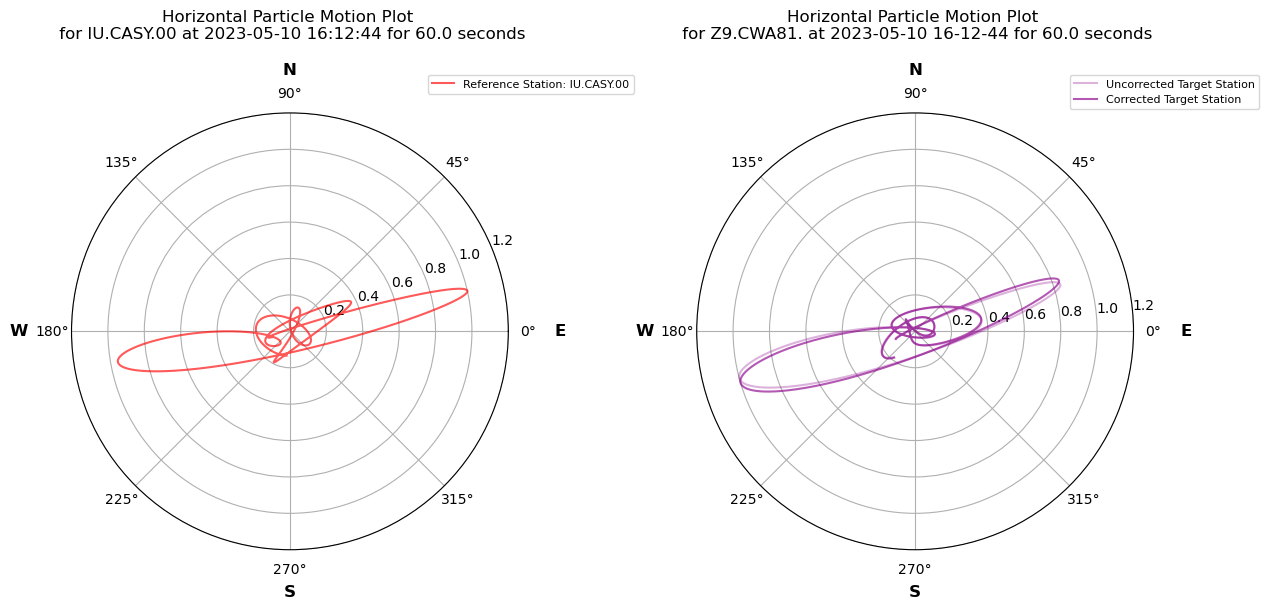

In [7]:
align.cc_correction(ref_dict = trim_ref, 
                    target_dict = trim_target,
                    NS_channel = ['BH1', 'HHN'],
                    EW_channel = ['BH2', 'HHE'],
                    col_n = 4,
                    underlying_plot='original', 
                    png_title='Example_Original_CC',
                    save_png=True)

CWA81 has an orientation of 1.55 degrees from CASY based on the above calculation.

Similarly, these results can also be tabulated. 

tabulate_cc_correction() applies the same process as cc_correction() except it tabulates instead of plotting.

In [8]:
align.tabulate_cc_correction(ref_dict = trim_ref,
                            target_dict = trim_target,
                            NS_channel = ['BH1', 'HHN'],
                            EW_channel = ['BH2', 'HHE'],
                            location = 'Example')

Processing reference station: IU.CASY.00...
Processing Z9.CWA81....
Alignments for Example Earthquake @ 2023-05-10 16-12-44 (UTC):


,Station,Angle Correction
0,Z9.CWA81.,1.55


## 5. Correcting Sensor Orientation

Now that the orientation relative to CASY is known for the target senser, its waveform data can be corrected.

rotate_stream() corrects the waveform for the orientation of the sensor. 

NS_channel is the north-south sensor channels.

EW_channel is the east-west sensor channels.

Z_channel is the vertical sensor channels.

A dictionary of seismic data can be input or a previous mseed file can be opened and processed.

There is the option to save the final waveform data as an mseed file. If the file is already saved, then the function reads the file instead. 

In [9]:
target_dict['Z9.CWA81.']

[Z9.CWA81..HHE | 2023-05-10T15:00:00.000000Z - 2023-05-10T17:00:00.000000Z | 100.0 Hz, 720001 samples,
 Z9.CWA81..HHN | 2023-05-10T15:00:00.000000Z - 2023-05-10T17:00:00.000000Z | 100.0 Hz, 720001 samples,
 Z9.CWA81..HHZ | 2023-05-10T15:00:00.000000Z - 2023-05-10T17:00:00.000000Z | 100.0 Hz, 720001 samples]

In [10]:
rotated_target = process.rotate_stream(wave_dict = target_dict,
                                      NS_channel = ['HHN'],
                                      EW_channel = ['HHE'],
                                      Z_channel = ['HHZ'],
                                      misalignment_angle = [1.55],
                                      save_mseed = False,
                                      config = config,
                                      read_file = False, # Switch to True to read and process a saved "filename".mseed file.
                                      filename = 'CWA81_rotated')

Processing Z9.CWA81....


The seismic waveform data is now corrected for its orientation.

In [11]:
rotated_target

defaultdict(list,
            {'Z9.CWA81.': 3 Trace(s) in Stream:
Z9.CWA81..HHE | 2023-05-10T15:00:00.000000Z - 2023-05-10T16:59:59.990000Z | 100.0 Hz, 720000 samples
Z9.CWA81..HHN | 2023-05-10T15:00:00.000000Z - 2023-05-10T16:59:59.990000Z | 100.0 Hz, 720000 samples
Z9.CWA81..HHZ | 2023-05-10T15:00:00.000000Z - 2023-05-10T16:59:59.990000Z | 100.0 Hz, 720000 samples})